# Conformal Prediction for Image Classification on SVHN

This notebook applies **split conformal prediction** to a convolutional neural network trained on the **Street View House Numbers (SVHN)** dataset, following the framework and evaluation methodologies in [Angelopoulos & Bates (2021), *A Gentle Introduction to Conformal Prediction and Distribution-Free Uncertainty Quantification*](https://arxiv.org/pdf/2107.07511).

SVHN consists of real-world $32 \times 32$ RGB images cropped from Google Street View house numbers, featuring natural lighting variations, blur, shadows, and distracting neighbor digits. This provides an effective benchmark for uncertainty quantification.

Key steps demonstrated:
- Split CP implementation using the LAC (softmax) nonconformity score,
- Empirical verification of the marginal coverage guarantee across different error levels $\alpha$,
- Analysis of prediction set sizes (empty sets, singletons, and multi-class sets),
- Visual inspection of prediction sets on real street-view images,
- Evaluating adaptivity via Feature-Stratified Coverage (FSC) and Size-Stratified Coverage (SSC) (Paper Section 3.1),
- Simulation-based correctness checks via fast score caching and Beta-Binomial moments (Paper Section 3.3 & Appendix C).


## 0 · Imports and Device Setup

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from scipy import stats
from torch import nn
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


## 1 · Conformal Prediction — Quick Recap

The general conformal prediction framework (marginal guarantee, 3-step recipe, and quantile formula) follows **Section 1 & 1.1** ("Instructions for Conformal Prediction") of Angelopoulos & Bates (2021).

For multi-class image classification, we use the standard **LAC (Least Ambiguous set-valued Classifier)** / softmax nonconformity score (**Section 2**, "Choice of score function").

### LAC Nonconformity Score

$$
s(x, y) = 1 - \hat{f}_y(x)
$$

where $\hat{f}_y(x)$ is the model predicted softmax probability for class $y$. Confident and correct predictions have $s(x, y) \approx 0$, while uncertain or wrong predictions yield higher scores closer to 1.

### Prediction Set

At test time, candidate label $y$ is included in the prediction set $\hat{C}_\alpha(x)$ when its softmax probability clears the threshold $1 - \hat{q}$ (**Section 1.1, Step 4**):

$$
\hat{C}_\alpha(x) = \bigl\{\, y \in \{0,\ldots,9\} : \hat{f}_y(x) \geq 1 - \hat{q} \,\bigr\}
$$

## 2 · Data — Three-way Split

SVHN contains a training split (73,257 images) and a test split (26,032 images). We create three disjoint splits:

| Set | Size | Purpose |
|-----|------|---------|
| **Train** | 73 257 | Fit the CNN parameters |
| **Calibration** | 13 016 | Compute the empirical quantile $\hat{q}$ |
| **Test** | 13 016 | Evaluate empirical coverage and set sizes |

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4377, 0.4438, 0.4728), (0.1980, 0.2010, 0.1970))
])

train_dataset = datasets.SVHN('./data', split='train', download=True, transform=transform)
test_full     = datasets.SVHN('./data', split='test',  download=True, transform=transform)

# Split the full test set into non-overlapping calibration and test sets
n_cal  = len(test_full) // 2
n_test = len(test_full) - n_cal
cal_dataset, test_dataset = random_split(
    test_full, [n_cal, n_test],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True,  num_workers=0,
                          generator=torch.Generator().manual_seed(SEED))
cal_loader   = DataLoader(cal_dataset,   batch_size=512, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=512, shuffle=False, num_workers=0)

print(f'Train: {len(train_dataset):,}  |  Calibration: {len(cal_dataset):,}  |  Test: {len(test_dataset):,}')

100%|██████████| 182M/182M [00:49<00:00, 3.65MB/s] 
100%|██████████| 64.3M/64.3M [00:15<00:00, 4.12MB/s]


Train: 73,257  |  Calibration: 13,016  |  Test: 13,016


## 3 · Model — CNN for $32 \times 32$ RGB Digits

We train a 3-block convolutional network with batch normalization to handle RGB street view digits.

In [3]:
class SVHNNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc1   = nn.Linear(128 * 4 * 4, 256)
        self.fc2   = nn.Linear(256, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = x.flatten(1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

In [4]:
def train_one_epoch(model, loader, optimiser):
    model.train()
    total_loss = 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimiser.zero_grad()
        loss = F.cross_entropy(model(images), labels)
        loss.backward()
        optimiser.step()
        total_loss += loss.item() * len(images)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def accuracy(model, loader):
    model.eval()
    correct = sum(
        (model(images.to(DEVICE)).argmax(1) == labels.to(DEVICE)).sum().item()
        for images, labels in loader
    )
    return correct / len(loader.dataset)


model = SVHNNet().to(DEVICE)
optimiser = torch.optim.Adam(model.parameters(), lr=1e-3)

N_EPOCHS = 3
for epoch in range(1, N_EPOCHS + 1):
    loss = train_one_epoch(model, train_loader, optimiser)
    acc  = accuracy(model, test_loader)
    print(f'Epoch {epoch}/{N_EPOCHS}  loss={loss:.4f}  test-acc={acc:.4f}')

Epoch 1/3  loss=1.0527  test-acc=0.8513
Epoch 2/3  loss=0.3931  test-acc=0.8837
Epoch 3/3  loss=0.3107  test-acc=0.8841


## 4 · Nonconformity Scores on the Calibration Set

We evaluate the model on the held-out calibration set and compute the nonconformity score for the true label: $s(x, y) = 1 - \hat{f}_y(x)$.

In [23]:
@torch.no_grad()
def compute_softmax_scores(model, loader):
    """Returns (softmax_probs, true_labels) as numpy arrays."""
    model.eval()
    all_probs, all_labels = [], []
    for images, labels in loader:
        probs = F.softmax(model(images.to(DEVICE)), dim=-1).cpu()
        all_probs.append(probs)
        all_labels.append(labels)
    return torch.cat(all_probs).numpy(), torch.cat(all_labels).numpy()


cal_probs, cal_labels = compute_softmax_scores(model, cal_loader)

# Nonconformity score for the true class
cal_scores = 1 - cal_probs[np.arange(len(cal_labels)), cal_labels]

print(
    f"Calibration Scores (1 - P(true_class)):\n"
    f"  Min:  {cal_scores.min():.4f}  -> Ideal (0.0 = 100% confident & correct)\n"
    f"  Mean: {cal_scores.mean():.4f}  -> Lower is better (on average, the model assigns {1 - cal_scores.mean():.1%} probability to the correct digit)\n"
    f"  Max:  {cal_scores.max():.4f}  -> Worst miss (1.0 = true class received ~0% softmax probability)"
)

Calibration Scores (1 - P(true_class)):
  Min:  0.0000  -> Ideal (0.0 = 100% confident & correct)
  Mean: 0.1773  -> Lower is better (on average, the model assigns 82.3% probability to the correct digit)
  Max:  1.0000  -> Worst miss (1.0 = true class received ~0% softmax probability)


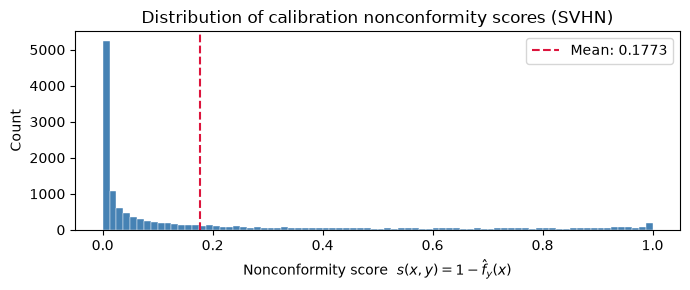

In [25]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(cal_scores, bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
mean_val = cal_scores.mean()
ax.axvline(mean_val, color='crimson', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.4f}')
ax.set_xlabel('Nonconformity score  $s(x, y) = 1 - \\hat{f}_y(x)$')
ax.set_ylabel('Count')
ax.set_title('Distribution of calibration nonconformity scores (SVHN)')
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

## 5 · Calibration — Computing $\hat{q}$

Next comes the critical step: define $\hat{q}$ to be the $\frac{\lceil (n+1)(1-\alpha) \rceil}{n}$ empirical quantile of $s_1, \ldots, s_n$, where $\lceil \cdot \rceil$ is the ceiling function ($\hat{q}$ is essentially the $1 - \alpha$ quantile, but with a small correction).


In [29]:
def calibration_quantile(scores: np.ndarray, alpha: float) -> tuple[float, int]:
    """Return the exact k-th order statistic and its rank index k."""
    n = len(scores)
    k = min(math.ceil((1 - alpha) * (n + 1)), n)
    q = float(np.sort(scores)[k - 1])
    return q, k


alpha = 0.10
q_hat, k = calibration_quantile(cal_scores, alpha)
threshold = 1 - q_hat
n = len(cal_scores)

print(f"Coverage target: {1 - alpha:.0%} (alpha = {alpha})")
print(f"Quantile index:  k = {k:,} / {n:,} sorted scores ({k / n:.1%})")
print(f"q_hat = {q_hat:.4f} (value of the {k:,}th sorted score)  →  threshold = {threshold:.4f}")
print(f"A class is included in C(x) iff its softmax prob >= {threshold:.4f}")

Coverage target: 90% (alpha = 0.1)
Quantile index:  k = 11,716 / 13,016 sorted scores (90.0%)
q_hat = 0.7008 (value of the 11,716th sorted score)  →  threshold = 0.2992
A class is included in C(x) iff its softmax prob >= 0.2992


## 6 · Prediction Sets on the Test Set

In [30]:
def prediction_sets(softmax_probs: np.ndarray, q_hat: float) -> list[set]:
    """Returns one prediction set per row of softmax_probs."""
    threshold = 1 - q_hat
    return [set(np.where(row >= threshold)[0]) for row in softmax_probs]


test_probs, test_labels = compute_softmax_scores(model, test_loader)
sets_at_90 = prediction_sets(test_probs, q_hat)

# 1. Check whether each true label is inside its prediction set (True/False)
covered = [true_label in pred_set for true_label, pred_set in zip(test_labels, sets_at_90)]
n_covered = sum(covered)
n_total = len(test_labels)
empirical_coverage = n_covered / n_total

print(f"Covered images:     {n_covered:,} / {n_total:,} ({empirical_coverage:.2%})")
print(f"Target coverage:    {1 - alpha:.0%}  |  Empirical coverage: {empirical_coverage:.2%}")
print("Note: On a single finite test batch, empirical coverage fluctuates naturally around 90%")
print("due to calibration draw and binomial test variance (e.g. 89.1% - 90.9%).")

Covered images:     11,765 / 13,016 (90.39%)
Target coverage:    90%  |  Empirical coverage: 90.39%
Note: On a single finite test batch, empirical coverage fluctuates naturally around 90%
due to calibration draw and binomial test variance (e.g. 89.1% - 90.9%).


### Interpretation of the Guarantee

By **Theorem 1** of Angelopoulos & Bates (2021), under exchangeability of the calibration and test data, the prediction set satisfies the marginal coverage guarantee:

$$
\mathbb{P}\bigl(Y_{\text{test}} \in \hat{C}_\alpha(X_{\text{test}})\bigr) \;\geq\; 1 - \alpha
$$

Key properties:
- The guarantee applies to the **entire process** across random draws of calibration sets and test points.
- For any single frozen calibration set and finite test batch, empirical coverage naturally exhibits small statistical fluctuations around $1 - \alpha$ (e.g. 89.1% to 90.9% for a 90% target).
- Over repeated evaluations and fresh draws, the expected coverage is at least $1 - \alpha$.


## 7 · Coverage Verification — Sweeping $\alpha$

We evaluate empirical coverage over a sweep of $\alpha \in [0.01, 0.30]$.

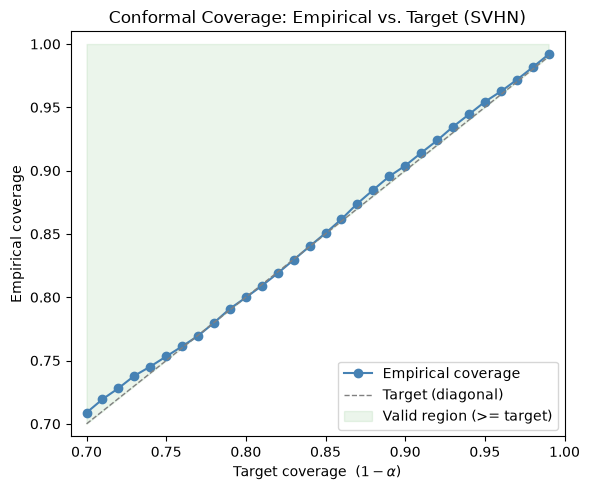

Mean deviation from target: +0.30 pp


In [31]:
alphas = np.linspace(0.01, 0.30, 30)

empirical_coverages = []
for a in alphas:
    q, _ = calibration_quantile(cal_scores, a)
    sets = prediction_sets(test_probs, q)
    coverage = np.mean([label in s for label, s in zip(test_labels, sets)])
    empirical_coverages.append(coverage)

target_coverages = 1 - alphas

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(target_coverages, empirical_coverages, 'o-', color='steelblue', label='Empirical coverage')
ax.plot([target_coverages.min(), target_coverages.max()],
        [target_coverages.min(), target_coverages.max()],
        '--', color='gray', linewidth=1, label='Target (diagonal)')
ax.fill_between(target_coverages, target_coverages, 1,
                alpha=0.08, color='green', label='Valid region (>= target)')
ax.set_xlabel('Target coverage  $(1 - \\alpha)$')
ax.set_ylabel('Empirical coverage')
ax.set_title('Conformal Coverage: Empirical vs. Target (SVHN)')
ax.legend()
ax.set_xlim(target_coverages.min() - 0.01, target_coverages.max() + 0.01)
ax.set_ylim(target_coverages.min() - 0.01, 1.01)
plt.tight_layout()
plt.show()

mean_dev = np.mean(np.array(empirical_coverages) - target_coverages) * 100
print(f'Mean deviation from target: +{mean_dev:.2f} pp')

## 8 · Prediction Set Size Distribution

Following the discussion in **Section 3.1** ("Evaluating Adaptivity: Set size") of Angelopoulos & Bates (2021), plotting set sizes evaluates efficiency (smaller average size) and spread. Because SVHN images contain natural blur, perspective distortions, and real-world clutter, conformal prediction produces a healthy distribution across set sizes:

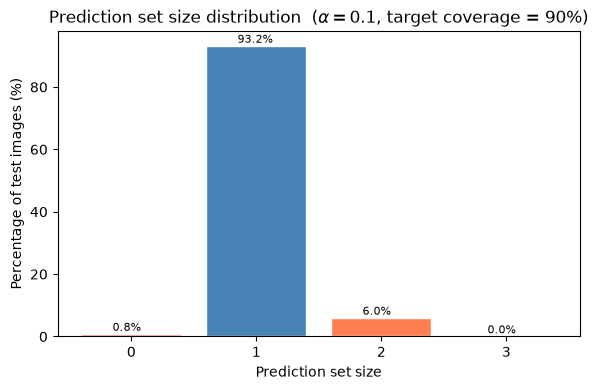

Set size 0:   106 ( 0.81%)
Set size 1: 12129 (93.19%)
Set size 2:   779 ( 5.98%)
Set size 3:     2 ( 0.02%)


In [10]:
set_sizes = [len(s) for s in sets_at_90]  # alpha=0.10
unique_sizes, counts = np.unique(set_sizes, return_counts=True)

fig, ax = plt.subplots(figsize=(6, 4))
bar_colors = ['salmon' if sz == 0 else ('coral' if sz >= 2 else 'steelblue') for sz in unique_sizes]
ax.bar(unique_sizes, counts / len(set_sizes) * 100, color=bar_colors, edgecolor='white')
ax.set_xlabel('Prediction set size')
ax.set_ylabel('Percentage of test images (%)')
ax.set_title(f'Prediction set size distribution  ($\\alpha = {alpha}$, target coverage = {1 - alpha:.0%})')
ax.set_xticks(unique_sizes)

for sz, cnt in zip(unique_sizes, counts):
    pct = cnt / len(set_sizes) * 100
    ax.annotate(f'{pct:.1f}%', xy=(sz, pct), xytext=(sz - 0.15, pct + 1), fontsize=8)

plt.tight_layout()
plt.show()

for sz, cnt in zip(unique_sizes, counts):
    pct = cnt / len(set_sizes) * 100
    print(f'Set size {sz}: {cnt:5d} ({pct:5.2f}%)')

## 9 · Visualising Prediction Sets

We inspect actual SVHN test images corresponding to:
- **Empty sets (size 0)** — difficult images where no digit cleared the required confidence threshold.
- **Singleton sets (size 1)** — the model is confident in a single digit,
- **Multi-class sets (size $\geq 2$)** — ambiguous images where multiple digits are plausible,

In [11]:
# Load raw (unnormalized) test subset for visualization
raw_test_data   = datasets.SVHN('./data', split='test', download=False, transform=transforms.ToTensor())
raw_test_subset = Subset(raw_test_data, test_dataset.indices)

# Index test examples by their prediction set size
size_to_indices: dict[int, list[int]] = {}
for i, s in enumerate(sets_at_90):
    size_to_indices.setdefault(len(s), []).append(i)


def show_prediction_set_examples(size: int, n_cols: int = 6):
    indices = size_to_indices.get(size, [])
    if not indices:
        print(f'No examples with set size {size}')
        return
    sample = indices[:n_cols]
    fig, axes = plt.subplots(1, len(sample), figsize=(len(sample) * 2, 2.5))
    if len(sample) == 1:
        axes = [axes]
    for ax, idx in zip(axes, sample):
        image, _ = raw_test_subset[idx]
        pred_set = sets_at_90[idx]
        true_label = test_labels[idx]
        # Convert tensor (C, H, W) to (H, W, C) for display
        ax.imshow(image.permute(1, 2, 0).numpy())
        set_str = '{' + ', '.join(str(c) for c in sorted(pred_set)) + '}' if pred_set else '∅'
        covered = true_label in pred_set
        ax.set_title(f'True: {true_label}\n$\\hat{{C}}$ = {set_str}',
                     color='green' if covered else 'red', fontsize=9)
        ax.axis('off')
    fig.suptitle(f'Set size = {size}', fontweight='bold')
    plt.tight_layout()
    plt.show()

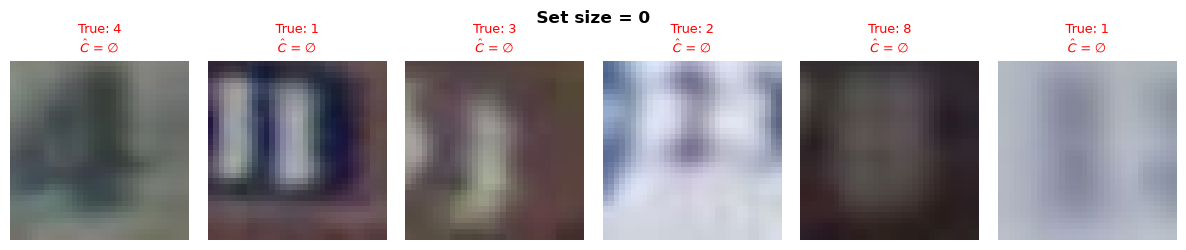

In [12]:
show_prediction_set_examples(size=0)  # Uncertain: no digit cleared the threshold

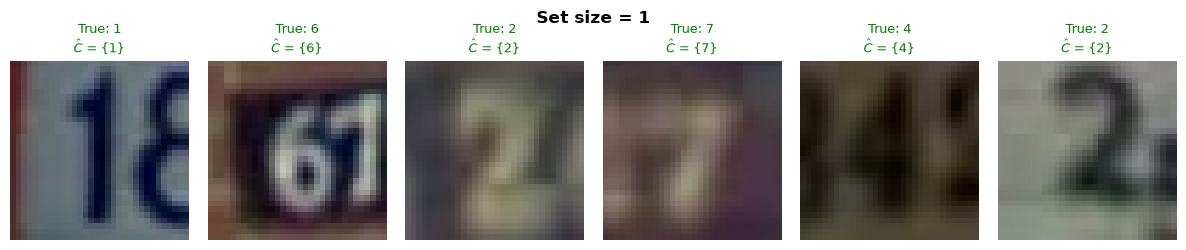

In [13]:
show_prediction_set_examples(size=1)  # Confident predictions

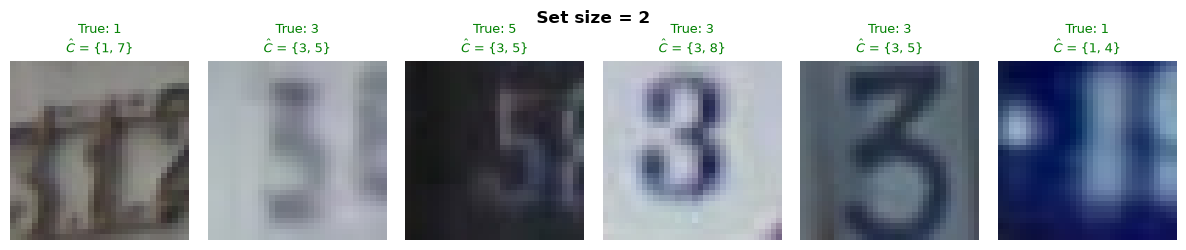

In [14]:
show_prediction_set_examples(size=2)  # Ambiguous predictions: two plausible digits

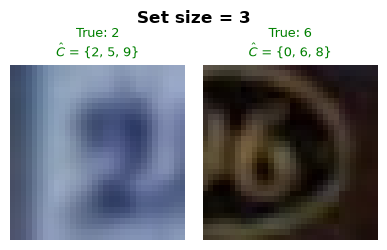

In [32]:
show_prediction_set_examples(size=3)  # Ambiguous predictions: three plausible digits

## 10 — Evaluating Adaptivity (Paper Section 3.1)

As formalized in **Section 3.1** of Angelopoulos & Bates (2021), the standard guarantee ensures **marginal coverage** over the distribution:
$$\mathbb{P}(Y_{\text{test}} \in C(X_{\text{test}})) \ge 1 - \alpha$$

However, this does not guarantee **conditional coverage** (Eq. 7 in the paper):
$$\mathbb{P}(Y_{\text{test}} \in C(X_{\text{test}}) \mid X_{\text{test}}) \ge 1 - \alpha$$

A trivial procedure could achieve 90% marginal coverage by covering 100% of easy examples and 0% of hard examples. A practically useful conformal predictor must be **adaptive**: producing smaller sets for easy inputs and larger sets for difficult or ambiguous inputs to faithfully reflect model uncertainty.

To evaluate adaptivity, we compute two standard metrics from Section 3.1 of the paper:
1. **Feature-Stratified Coverage (FSC)**: worst-case coverage across discrete feature groups (here, ground-truth digit classes).
2. **Size-Stratified Coverage (SSC)**: worst-case coverage across prediction set cardinality bins.

### Feature-Stratified Coverage (FSC, Paper Section 3.1)

For discrete groups $g \in \{1, \dots, G\}$ (such as digit labels $0, \dots, 9$), the FSC metric defined in **Section 3.1** of Angelopoulos & Bates (2021) measures the minimum coverage across all groups:
$$\text{FSC} = \min_{g \in \{1, \dots, G\}} \frac{1}{|I_g|} \sum_{i \in I_g} \mathbf{1}\{Y_i \in C(X_i)\}$$

If exact conditional coverage held, every digit would achieve $\ge 1 - \alpha$.

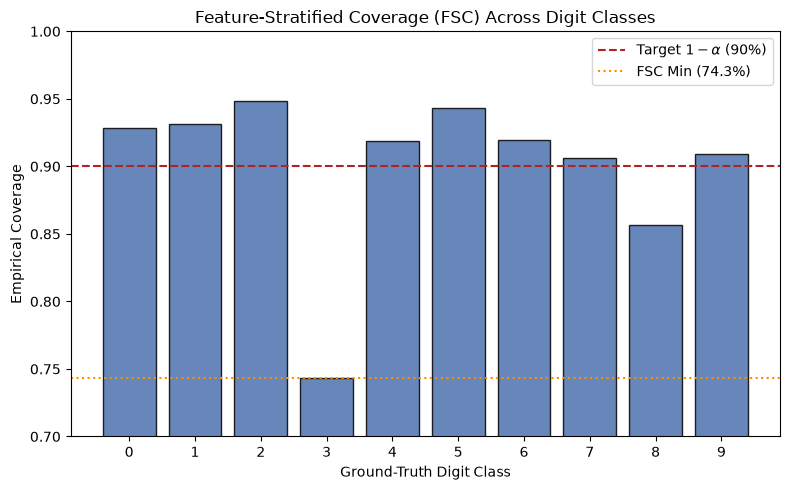

Feature-Stratified Coverage (FSC) = min_g Coverage(g): 74.31%
  Digit 0: 92.87% (n=884)
  Digit 1: 93.10% (n=2567)
  Digit 2: 94.82% (n=2066)
  Digit 3: 74.31% (n=1448)
  Digit 4: 91.90% (n=1271)
  Digit 5: 94.33% (n=1218)
  Digit 6: 91.94% (n=980)
  Digit 7: 90.62% (n=992)
  Digit 8: 85.64% (n=822)
  Digit 9: 90.89% (n=768)

Interpretation:
Standard conformal prediction guarantees 90% coverage on average across the entire
dataset, but not on each individual class. FSC highlights the hardest class (Digit 3 at 74.3%),
which is under-covered while easier classes over-cover to maintain the overall 90% average.
To guarantee 90% coverage for every class, use class-conditional conformal prediction.


In [ ]:
# Feature-Stratified Coverage (FSC) across digit classes
test_covered = np.array([label in s for label, s in zip(test_labels, sets_at_90)])
class_coverages = {}
for digit in range(10):
    idx = np.where(test_labels == digit)[0]
    class_cov = np.mean(test_covered[idx])
    class_coverages[digit] = class_cov

fsc_metric = min(class_coverages.values())

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(list(class_coverages.keys()), list(class_coverages.values()), color="#4C72B0", edgecolor="black", alpha=0.85)
ax.axhline(0.90, color="firebrick", linestyle="--", linewidth=1.5, label=r"Target $1 - \alpha$ (90%)")
ax.axhline(fsc_metric, color="darkorange", linestyle=":", linewidth=1.5, label=f"FSC Min ({fsc_metric*100:.1f}%)")
ax.set_xticks(range(10))
ax.set_xlabel("Ground-Truth Digit Class")
ax.set_ylabel("Empirical Coverage")
ax.set_title("Feature-Stratified Coverage (FSC) Across Digit Classes")
ax.set_ylim(0.70, 1.0)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

print(f"Feature-Stratified Coverage (FSC) = min_g Coverage(g): {fsc_metric*100:.2f}%")
for digit, cov in class_coverages.items():
    print(f"  Digit {digit}: {cov*100:.2f}% (n={np.sum(test_labels == digit)})")

worst_class = min(class_coverages, key=class_coverages.get)
print("\nInterpretation:")
print(f"Standard conformal prediction guarantees {1 - alpha:.0%} coverage on average across the entire")
print(f"dataset, but not on each individual class. FSC highlights the hardest class (Digit {worst_class} at {fsc_metric:.1%}),")
print(f"which is under-covered while easier classes over-cover to maintain the overall {1 - alpha:.0%} average.")
print(f"To guarantee {1 - alpha:.0%} coverage for every class, use class-conditional conformal prediction.")

### Size-Stratified Coverage (SSC, Paper Section 3.1)

The SSC metric introduced in **Section 3.1** of Angelopoulos & Bates (2021) groups validation points by prediction set cardinality $|C(x)| \in B_g$ and measures coverage within each bin:
$$\text{SSC} = \min_{g} \frac{1}{|I_g|} \sum_{i \in I_g} \mathbf{1}\{Y_i \in C(X_i)\}$$

For size 0, coverage is trivially 0% (an empty set contains no true label). For informative sets ($|C(x)| \ge 1$), SSC indicates whether smaller or larger sets exhibit conditional undercoverage.

In [37]:
# Size-Stratified Coverage (SSC) across prediction set cardinalities
prediction_set_sizes = np.array(set_sizes)
test_covered_flags = np.array(test_covered)
observed_set_sizes = np.sort(np.unique(prediction_set_sizes))
size_stratified_stats = {}

for set_size in observed_set_sizes:
    matching_indices = np.where(prediction_set_sizes == set_size)[0]
    group_coverage = np.mean(test_covered_flags[matching_indices]) if len(matching_indices) > 0 else np.nan
    size_stratified_stats[set_size] = (len(matching_indices), group_coverage)

# SSC evaluates informative prediction sets (|C(x)| >= 1)
informative_set_sizes = [set_size for set_size in observed_set_sizes if set_size >= 1]
worst_size = min(informative_set_sizes, key=lambda set_size: size_stratified_stats[set_size][1])
ssc_metric = size_stratified_stats[worst_size][1]

print(f"Size-Stratified Coverage (SSC, |C| >= 1): {ssc_metric*100:.2f}%\n")
print(f"{'Set Size':<10} {'Count':<10} {'Proportion':<12} {'Coverage':<10}")
print("-" * 44)
for set_size in observed_set_sizes:
    group_count, group_coverage = size_stratified_stats[set_size]
    group_proportion = group_count / len(prediction_set_sizes) * 100
    coverage_display = f"{group_coverage*100:.2f}%" if not np.isnan(group_coverage) else "N/A"
    print(f"{set_size:<10} {group_count:<10} {group_proportion:>6.2f}%     {coverage_display:<10}")

print("\nInterpretation:")
print(f"Standard conformal prediction guarantees {1 - alpha:.0%} coverage on average, but coverage can")
print("vary depending on prediction set size. SSC evaluates conditional reliability by identifying")
print(f"the worst-performing set size (|C| = {worst_size} at {ssc_metric:.1%}), showing whether sets of certain")
print("cardinalities experience conditional under-coverage while meeting the global target.")

Size-Stratified Coverage (SSC, |C| >= 1): 86.39%

Set Size   Count      Proportion   Coverage  
--------------------------------------------
0          106          0.81%     0.00%     
1          12129       93.19%     91.43%    
2          779          5.98%     86.39%    
3          2            0.02%     100.00%   

Interpretation:
Standard conformal prediction guarantees 90% coverage on average, but coverage can
vary depending on prediction set size. SSC evaluates conditional reliability by identifying
the worst-performing set size (|C| = 2 at 86.4%), showing whether sets of certain
cardinalities experience conditional under-coverage while meeting the global target.


## 11 — Correctness Checks via Fast Score Caching (Paper Section 3.3, Figure 12 & Appendix C)

To empirically verify that our implementation satisfies the theoretical guarantees without confounding from a single split, we follow the multi-trial simulation diagnostic in **Section 3.3** of Angelopoulos & Bates (2021) over $R = 250$ trials.

### Efficient Score Caching (Figure 12)
Re-evaluating the neural network on every split is unnecessary. Following the fast algorithm in **Figure 12** of the paper:
1. We precompute nonconformity scores $s_i = 1 - \hat{f}_{y_i}(x_i)$ for the combined calibration and test pool ($N = 26{,}032$).
2. In each trial $r = 1, \dots, R$, we randomly permute and split the cached scores into calibration ($n = 13{,}016$) and validation ($n_{\text{val}} = 13{,}016$).
3. We compute $\hat{q}$ and evaluate empirical coverage.

### Finite-Sample Concentration (Appendix C)
Because both calibration set size $n$ and validation set size $n_{\text{val}}$ are finite, each trial coverage $C_j$ is distributed as a scaled Beta-Binomial random variable (**Appendix C** of the paper):
$$C_j \sim \frac{1}{n_{\text{val}}} \mathrm{BetaBinom}(n_{\text{val}},\; n + 1 - l,\; l)$$
with theoretical mean and standard deviation:
$$\mathbb{E}[C_j] = 1 - \frac{l}{n + 1}, \qquad \sigma = \sqrt{\frac{l(n + 1 - l)(n + n_{\text{val}} + 1)}{n_{\text{val}}(n + 1)^2(n + 2)}}$$

In [ ]:
# Precompute and pool nonconformity scores for combined calibration + test sets
test_scores = 1.0 - test_probs[np.arange(len(test_labels)), test_labels]
pooled_scores = np.concatenate([cal_scores, test_scores])
n_pool = len(pooled_scores)
n_cal = len(cal_scores)
n_val = n_pool - n_cal

R = 250
alpha = 0.10
trial_coverages = np.zeros(R)

# Run R random splits using cached scores
rng = np.random.default_rng(seed=SEED)
for r in range(R):
    perm = rng.permutation(pooled_scores)
    cal_subset, val_subset = perm[:n_cal], perm[n_cal:]
    qhat_r, _ = calibration_quantile(cal_subset, alpha)
    trial_coverages[r] = (val_subset <= qhat_r).mean()

# Theoretical moments from Appendix C
l_val = int((n_cal + 1) * alpha)
mean_theory = 1.0 - l_val / (n_cal + 1)
var_theory = (l_val * (n_cal + 1 - l_val) * (n_cal + n_val + 1)) / (n_val * ((n_cal + 1)**2) * (n_cal + 2))
std_theory = np.sqrt(var_theory)

print(f"Number of simulation trials: {R}")
print(f"Empirical Mean Coverage:     {trial_coverages.mean()*100:.3f}%  (Theoretical: {mean_theory*100:.3f}%)")
print(f"Empirical Std Deviation:     {trial_coverages.std()*100:.3f}%  (Theoretical: {std_theory*100:.3f}%)")

Number of simulation trials: 250
Empirical Mean Coverage:     89.999%  (Theoretical: 90.005%)
Empirical Std Deviation:     0.352%  (Theoretical: 0.372%)


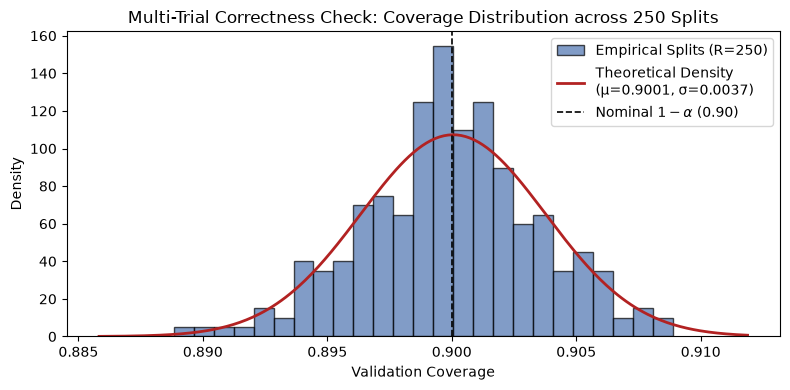


Interpretation:
By simulating 250 random calibration/validation splits, this diagnostic evaluates the algorithm
across repeated draws rather than relying on a single lucky or unlucky split. Comparing the
empirical coverage distribution (mean 90.00%, std 0.35%) against theoretical expectations
serves as a sanity check to verify the calibration logic behaves as intended by the theory.


In [39]:
fig, ax = plt.subplots(figsize=(8, 4))

# Empirical histogram across R trials
count, bins, _ = ax.hist(
    trial_coverages, bins=25, density=True, color="#4C72B0", edgecolor="black", alpha=0.7,
    label=f"Empirical Splits (R={R})"
)

# Theoretical Beta-Binomial Gaussian density overlay
x_norm = np.linspace(trial_coverages.min() - 0.003, trial_coverages.max() + 0.003, 300)
ax.plot(x_norm, stats.norm.pdf(x_norm, mean_theory, std_theory), color="firebrick", linewidth=2,
        label=f"Theoretical Density\n(μ={mean_theory:.4f}, σ={std_theory:.4f})")

ax.axvline(1 - alpha, color="black", linestyle="--", linewidth=1.2, label=r"Nominal $1 - \alpha$ (0.90)")
ax.set_title(f"Multi-Trial Correctness Check: Coverage Distribution across {R} Splits")
ax.set_xlabel("Validation Coverage")
ax.set_ylabel("Density")
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print(f"By simulating {R} random calibration/validation splits, this diagnostic evaluates the algorithm")
print("across repeated draws rather than relying on a single lucky or unlucky split. Comparing the")
print(f"empirical coverage distribution (mean {trial_coverages.mean():.2%}, std {trial_coverages.std():.2%}) against theoretical expectations")
print("serves as a sanity check to verify the calibration logic behaves as intended by the theory.")